# Import Libraries

In [ ]:
# Importing necessary libraries.
import numpy as npy
# When utilizing dataframes
import pandas as pds
# To visualize data
import matplotlib.pyplot as mplt
# Library of advanced visualization
import seaborn as sans
# To divide the dataset into sets for testing and training
from sklearn.model_selection import train_test_split
# Regression using a decision tree model
from sklearn.tree import DecisionTreeRegressor
# Ensemble techniques
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# Metrics for evaluation
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# To keep track of operating time (optional usage)
import time
# To normalize features to a predetermined range, typically [0, 1], import MinMaxScaler.
from sklearn.preprocessing import MinMaxScaler
# Turning off alerts to produce cleaner results
import warnings
warnings.filterwarnings('ignore')
# Regression model K-Nearest Neighbors
from sklearn.neighbors import KNeighborsRegressor
# Vector Regression Support
from sklearn.metrics import mean_squared_error
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Read File

In [ ]:
# Using a DataFrame to load the dataset for analysis from a CSV file
traffic_dfrm = pds.read_csv('/content/west_to_east.csv')

# Show Data

In [ ]:
# Presenting the dataset's initial records to provide a summary of the data structure
traffic_dfrm.head()

,Unnamed: 0,DateTime,Junction,Vehicles,day,week,month,year,hour
0,0,2023-01-01 00:00:00,1,340,1,6,1,2023,0
1,1,2023-01-01 01:00:00,1,320,1,6,1,2023,1
2,2,2023-01-01 02:00:00,1,320,1,6,1,2023,2
3,3,2023-01-01 03:00:00,1,280,1,6,1,2023,3
4,4,2023-01-01 04:00:00,1,280,1,6,1,2023,4


# Show Data Information

In [ ]:
# Examining column names, data types, and non-null counts by summarizing the dataset
traffic_dfrm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4342 entries, 0 to 4341
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  4342 non-null   int64 
 1   DateTime    4342 non-null   object
 2   Junction    4342 non-null   int64 
 3   Vehicles    4342 non-null   int64 
 4   day         4342 non-null   int64 
 5   week        4342 non-null   int64 
 6   month       4342 non-null   int64 
 7   year        4342 non-null   int64 
 8   hour        4342 non-null   int64 
dtypes: int64(8), object(1)
memory usage: 305.4+ KB


# Show columns

In [ ]:
# Listing the titles of every column in the dataset to comprehend the characteristics that are available
traffic_dfrm.columns

Index(['Unnamed: 0', 'DateTime', 'Junction', 'Vehicles', 'day', 'week',
       'month', 'year', 'hour'],
      dtype='object')

# Distribution Graphs

<Figure size 1600x1000 with 0 Axes>

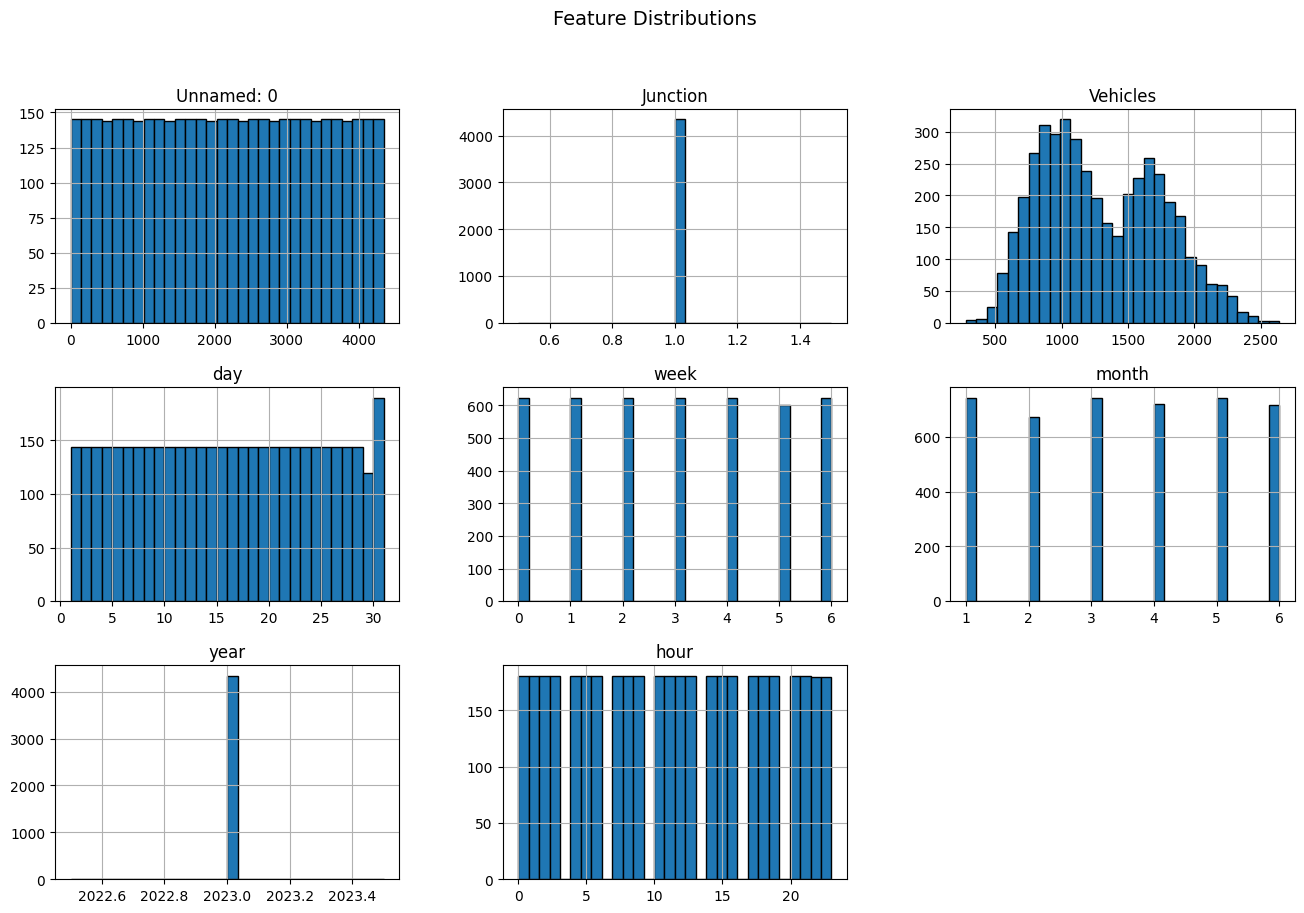

In [ ]:
#traffic_dfrm = traffic_dfrm.loc[:, traffic_dfrm.columns.str.contains('^Unnamed')]
mplt.figure(figsize=(16, 10))

# >>> Construct histograms to unveil numerical feature distributions <<<
traffic_dfrm.hist(bins=30,  # Fine-tune bin count to control granularity
        figsize=(16, 10),  # Ensure optimal figure proportions for readability
        edgecolor='black')  # Enhance visual distinction with black-edged bars
mplt.suptitle("Feature Distributions", fontsize=14)
mplt.show()


# Drop Column and Change Format

In [ ]:
# Eliminating the superfluous index column that is frequently produced during CSV export.
traffic_dfrm = traffic_dfrm.drop(columns=["Unnamed: 0"])
# Changing the text format of the 'DateTime' column to the appropriate datetime objects for time-based analysis.
traffic_dfrm["DateTime"] = pds.to_datetime(traffic_dfrm["DateTime"])

# Plot Vehicles Count by Day

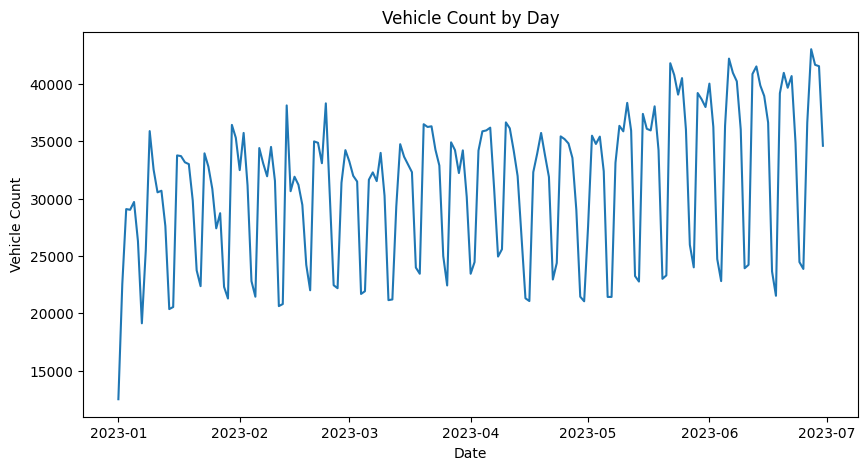

In [ ]:
# Confirming the conversion and making sure the 'DateTime' column is in datetime format
traffic_dfrm['DateTime'] = pds.to_datetime(traffic_dfrm['DateTime'])
# Compiling daily total vehicle counts and displaying the trend over time
traffic_dfrm.groupby(traffic_dfrm['DateTime'].dt.date)['Vehicles'].sum().plot(figsize=(10,5))
# Configuring the plot's title and axis labels
mplt.title('Vehicle Count by Day')
mplt.xlabel('Date')
mplt.ylabel('Vehicle Count')
mplt.show()

# Plot Vehicles Count by Months

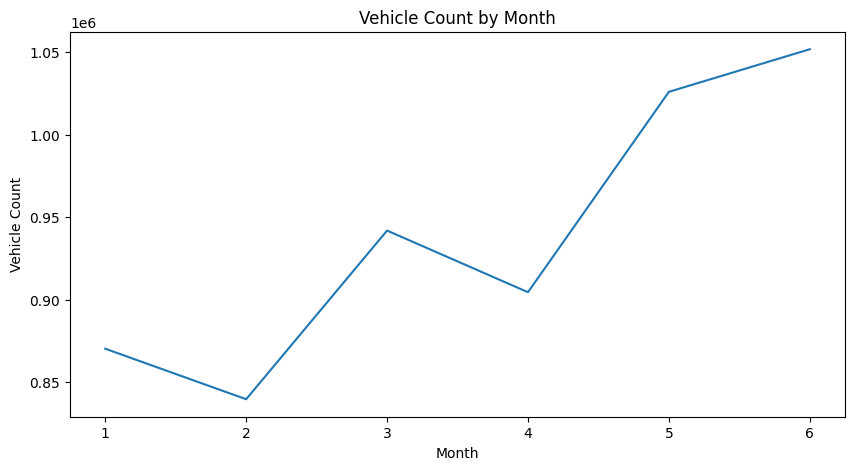

In [ ]:
# Compiling monthly vehicle counts to track monthly traffic trends
traffic_dfrm.groupby(traffic_dfrm['DateTime'].dt.month)['Vehicles'].sum().plot(figsize=(10,5))
# For clarity, identifying the axes and adding a title
mplt.title('Vehicle Count by Month')
mplt.xlabel('Month')
mplt.ylabel('Vehicle Count')
# Making the line plot visible
mplt.show()

# Traffic Flow Distribution

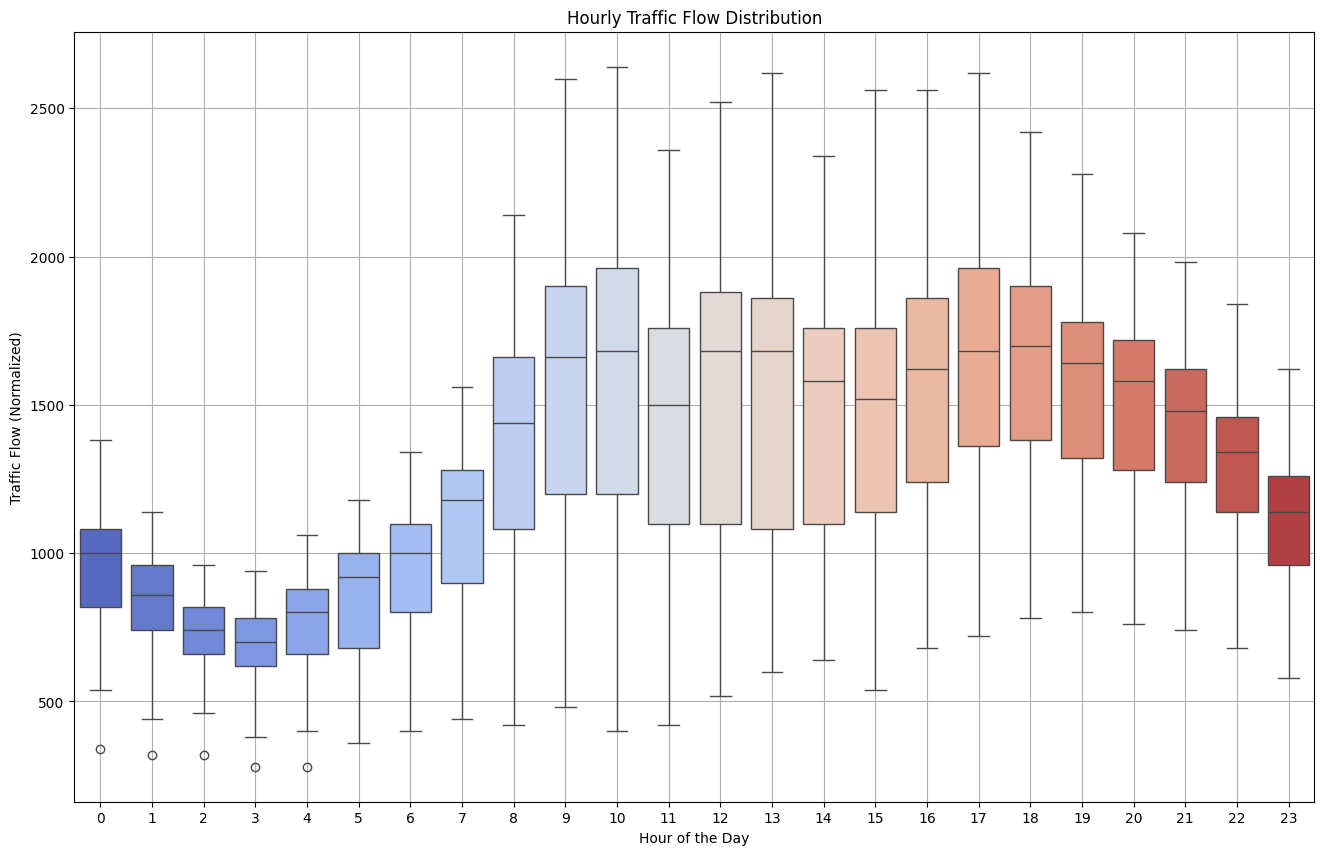

In [ ]:
#  Define canvas dimensions to optimize graphical clarity <<<
mplt.figure(figsize=(16, 10))

#  Construct a box plot to depict traffic flow variations across different hours <<<
sans.boxplot(x=traffic_dfrm["hour"], y=traffic_dfrm["Vehicles"], palette="coolwarm", legend=False)

# Annotate the x-axis to specify hourly intervals (0-23) <<<
mplt.xlabel("Hour of the Day")

#  Annotate the y-axis to illustrate the distribution of traffic intensity <<<
mplt.ylabel("Traffic Flow (Normalized)")

# Assign an informative title to contextualize the visualization <<<
mplt.title("Hourly Traffic Flow Distribution")

# Activate gridlines to enhance interpretability <<<
mplt.grid()

# Render the finalized box plot on screen <<<
mplt.show()

# Plot Average Vehicles by Hour

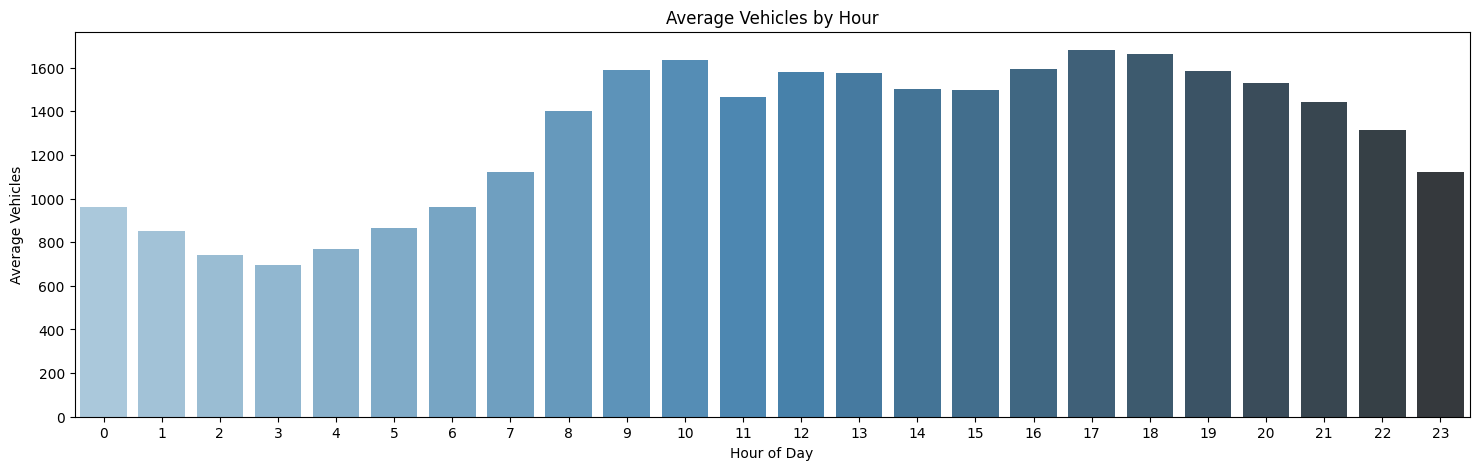

In [ ]:
# Drawing a broad image to clearly depict the hourly vehicle flow
fig, axes = mplt.subplots(figsize=(18, 5))
# Determining the typical hourly vehicle count for every day
vehicles_by_hour = traffic_dfrm.groupby(traffic_dfrm['DateTime'].dt.hour)['Vehicles'].mean()
# Making a bar plot with a blue color scheme to show hourly vehicle averages
sans.barplot(x=vehicles_by_hour.index, y=vehicles_by_hour.values, palette="Blues_d")
# Adding the chart's title and axis labels
axes.set_title('Average Vehicles by Hour')
axes.set_xlabel('Hour of Day')
axes.set_ylabel('Average Vehicles')
# Presenting the finished plot
mplt.show()

# Plot Vehicles by Day of Week

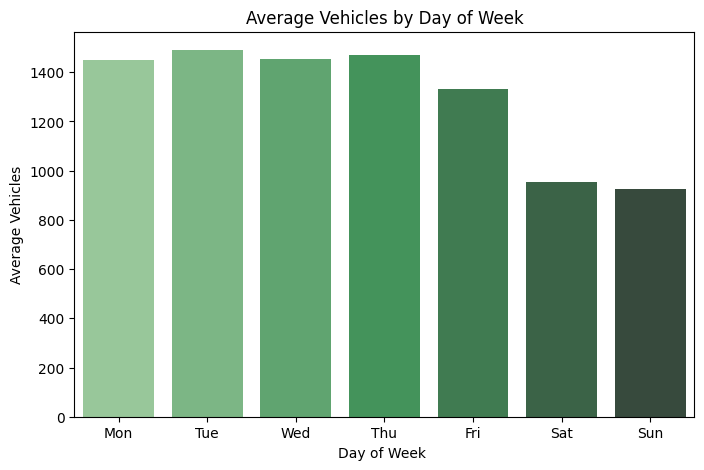

In [ ]:
# Specify the proper weekday order (0 = Monday, 6 = Sunday).
day_order = [0, 1, 2, 3, 4, 5, 6]
# Configure the plot's figure size.
fig, axes = mplt.subplots(figsize=(8, 5))
# Extract the DateTime column and group by day of the week.
vehicles_by_dayofweek = traffic_dfrm.groupby(traffic_dfrm['DateTime'].dt.dayofweek)['Vehicles'].mean().reindex(day_order)
# Make a bar plot that displays the typical number of vehicles for each day of the week.
sans.barplot(x=vehicles_by_dayofweek.index, y=vehicles_by_dayofweek.values, palette="Greens_d", order=day_order)
# Include axis labels and the plot title.
axes.set_title('Average Vehicles by Day of Week')
axes.set_xlabel('Day of Week ')
axes.set_ylabel('Average Vehicles')
# Add weekday labels to the x-axis to personalize it.
mplt.xticks(day_order, ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
# Show the plot
mplt.show()

# Plot Average Vehicles by Months

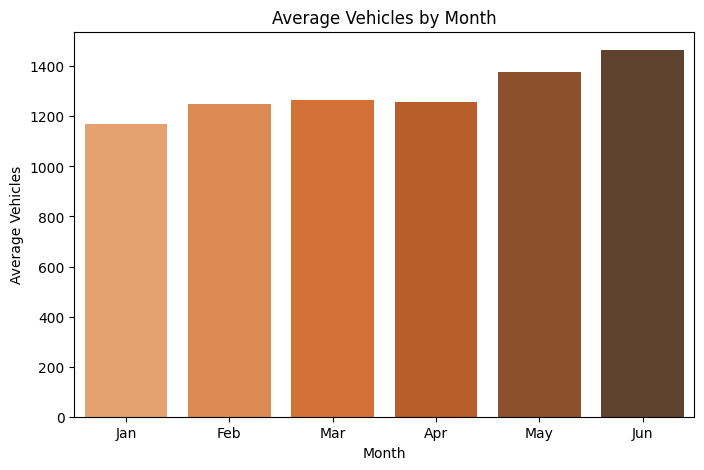

In [ ]:
# Making a bar plot to illustrate the daily variations in vehicle traffic
fig, axes = mplt.subplots(figsize=(8, 5))

# Calculating the average number of vehicles by grouping the data by day of the week (0 = Monday, 6 = Sunday)
vehicles_by_month = traffic_dfrm.groupby(traffic_dfrm['DateTime'].dt.month)['Vehicles'].mean()

# Using a color scheme with a green theme to visualize the typical vehicle flow throughout the day
sans.barplot(x=vehicles_by_month.index, y=vehicles_by_month.values, palette="Oranges_d")

# Including axis labels and the chart title for clarity
axes.set_title('Average Vehicles by Month')
axes.set_xlabel('Month')
axes.set_ylabel('Average Vehicles')

# Put the x-axis labels to month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
# Since the month index begins at 1, adjust the index by -1.
mplt.xticks(vehicles_by_month.index - 1, month_names)
# show the plot
mplt.show()


# Correlation Matrix

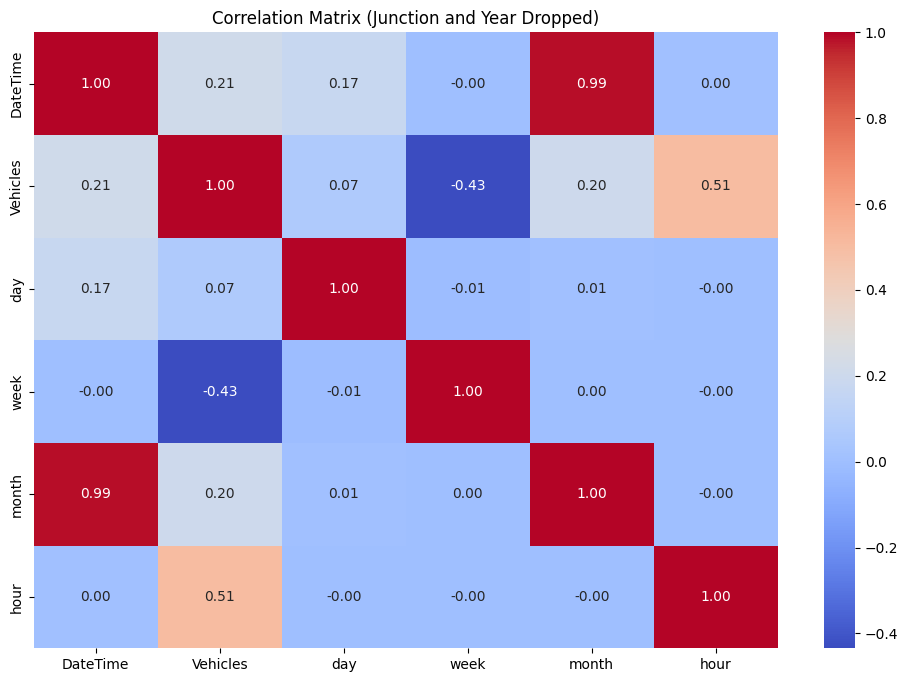

In [ ]:
# Making a duplicate of the dataset without the "Junction" and "year" columns, which might not be helpful for finding correlations
traffic_dfrm_dropped = traffic_dfrm.drop(columns=['Junction', 'year'])
# To investigate linear relationships between numerical features, compute the correlation matrix.
correlation_matrix = traffic_dfrm_dropped.corr()
# Configuring the figure size to create a heatmap that is understandable and clear
mplt.figure(figsize=(12, 8))
# Using a heatmap with annotations and a diverging color scale to visualize the correlation matrix
sans.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
# Giving the story a title to provide context
mplt.title('Correlation Matrix (Junction and Year Dropped)')
# Putting the heatmap on display
mplt.show()

# Feature Scalar

In [ ]:
# Since its data has probably been extracted into distinct time-based features, the 'DateTime' column is being removed.
traffic_dfrm = traffic_dfrm.drop(columns=['DateTime'])
# Apply MinMaxScaler to normalize feature values within the range [0,1] for consistency
scaler = MinMaxScaler()
traffic_dfrm[['Vehicles', 'hour', 'month']] = scaler.fit_transform(traffic_dfrm[['Vehicles', 'hour', 'month']])

# Convert DataFrame columns into NumPy arrays for seamless model ingestion
# Assuming 'Vehicles' is the target variable
Traffic_feat = ['hour', 'month'] # Independent feature columns
label_col = 'Vehicles' # Target variable column

data = traffic_dfrm[Traffic_feat].values  # Independent feature matrix
label = traffic_dfrm[label_col].values  # Target variable array

# Define a function to create sequential data points for modaling time-series data
def create_sequences(data, label, se_len=24):
    X, y = [], []
    for i in range(len(data) - se_len):
      # Iterate through dataset to extract sequences
        X.append(data[i : i + se_len])
        # Capture prior 'length' observations
        y.append(label[i + se_len])
        # Assign the next step as the target output
    return npy.array(X), npy.array(y)
    # Convert lists  NumPy arrays for efficient computation

# Set sequence length to 24, leveraging past 24-hour data to predict the upcoming hour
SE_LEN = 24
X, y = create_sequences(data, label, SE_LEN)


# Set Target Data

In [ ]:
# 'Vehicles' is the only column that is not used as a predictor.
X = traffic_dfrm.drop(columns=['Vehicles'])
# The variable we wish to predict is'vehicles'.
y = traffic_dfrm['Vehicles']

# Train Data

In [ ]:
# dividing the dataset into sets for testing and training
X_traffec_tran, X_traffec_tast, y_traffec_tran, y_traffec_tet = train_test_split(X, y, test_size=0.2, random_state=42)

# KNN Regressor Model

In [ ]:
# Create a dictionary with many K-Nearest Neighbors regressor modls in it.
knn_modls = {
    "KNN (n=2, leaf=60)": KNeighborsRegressor(n_neighbors=2, leaf_size=60),
    "KNN (n=3, leaf=60)": KNeighborsRegressor(n_neighbors=3, leaf_size=60),
    "KNN (n=5, leaf=60)": KNeighborsRegressor(n_neighbors=5, leaf_size=60),
}
# Make a blank dictionary to hold each model's evaluation results.
knn_results = {}
# Go through every model configuration in the dictionary one by one.
for name, model in knn_modls.items():
    # Use the training dataset to train (fit) the existing KNN model.
    model.fit(X_traffec_tran, y_traffec_tran)
    # Use the training data itself to generate predictions using the learned model.
    y_pred_train = model.predict(X_traffec_tran)
    # Use the trained model to produce predictions on the test (unseen) dataset.
    y_pred_test = model.predict(X_traffec_tast)

    # Determine the training data's Mean Absolute Error.
    mae_train = mean_absolute_error(y_traffec_tran, y_pred_train)
    # Using the training data, compute the Root Mean Squared Error.
    rmse_train = npy.sqrt(mean_squared_error(y_traffec_tran, y_pred_train))
    # Determine the training data's R-squared score, or coefficient of determination.
    r2_train = r2_score(y_traffec_tran, y_pred_train)

    # Determine the test data's Mean Absolute Error.
    mae_test = mean_absolute_error(y_traffec_tet, y_pred_test)
    # Determine the test data's Root Mean Squared Error.
    rmse_test = npy.sqrt(mean_squared_error(y_traffec_tet, y_pred_test))
    # Determine the test data's R-squared score.
    r2_test = r2_score(y_traffec_tet, y_pred_test)

    # Under the name of the model, store all computed performance measures in the results dictionary.
    knn_results[name] = {
        'train MAE': mae_train,
        'test MAE': mae_test,
        'train RMSE': rmse_train,
        'test RMSE': rmse_test,
        'train R²': r2_train,
        'test R²': r2_test
    }
# Create a pandas DataFrame from the dictionary of performance metrics.
knn_results_traffic_dfrm = pds.DataFrame.from_dict(knn_results, orient='index')
# To show that the following outcomes match, print a title for the output.
print("\nKNN Model Performance Summary:")
# Show the DataFrame with all of the evaluation metrics that was produced.
display(knn_results_traffic_dfrm)



KNN Model Performance Summary:


,train MAE,test MAE,train RMSE,test RMSE,train R²,test R²
"KNN (n=2, leaf=60)",0.026652,0.042948,0.035726,0.060784,0.965557,0.896927
"KNN (n=3, leaf=60)",0.028561,0.049846,0.040379,0.067994,0.956003,0.871026
"KNN (n=5, leaf=60)",0.042415,0.055770,0.056735,0.074135,0.913138,0.846674


# Comparison of KNN Model

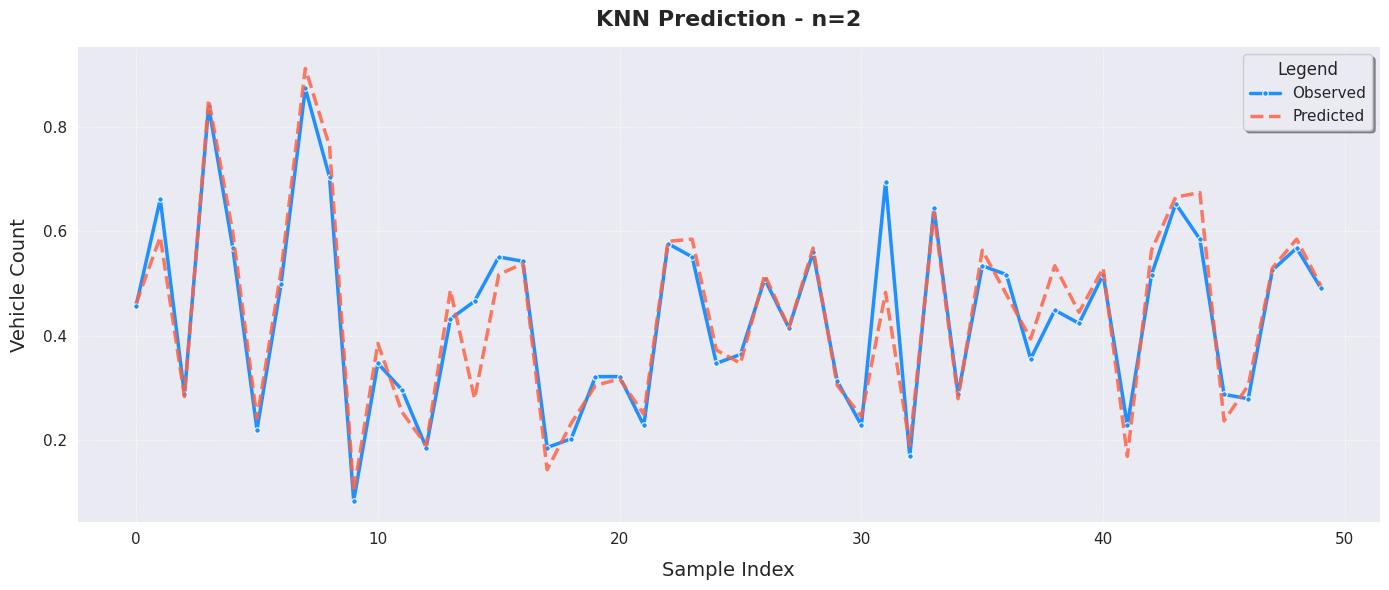

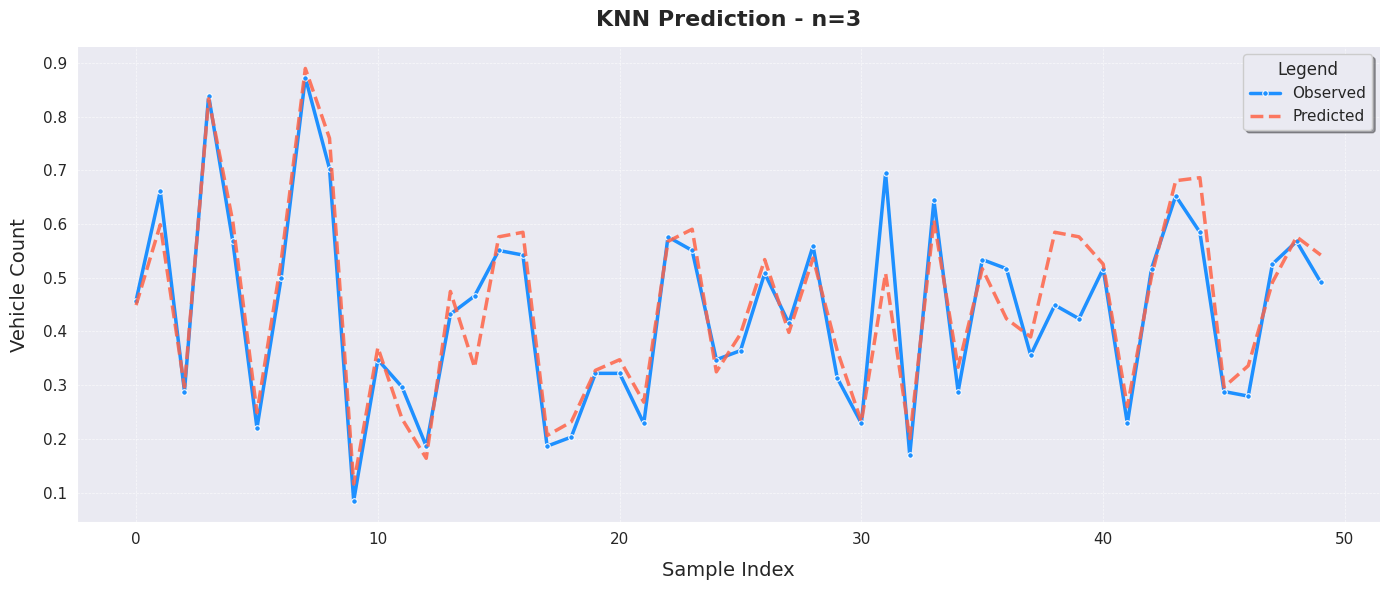

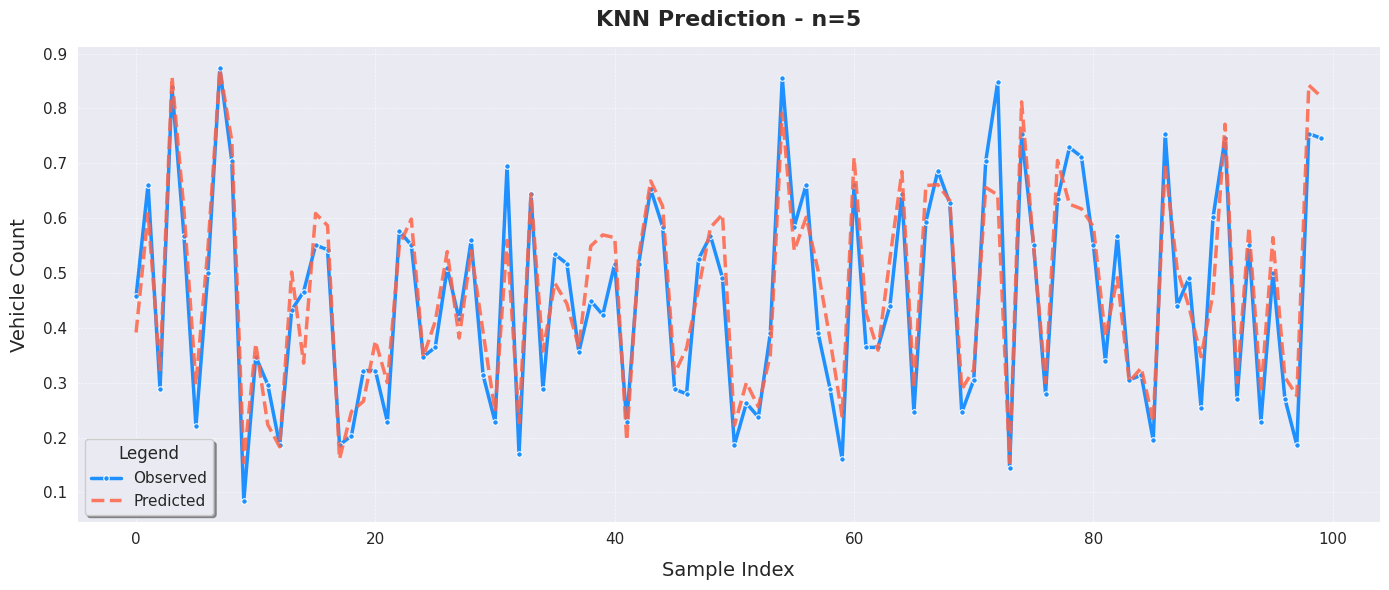

In [ ]:
# specifies a blank dictionary that will be used to hold each KNN model's test dataset predictions.
knn_predictions = {}
# initiates a loop that goes through every model in the KNN configuration dictionary that was previously defined.
for name, model in knn_modls.items():
  # uses the target data and training feature to train the existing KNN model.
    model.fit(X_traffec_tran, y_traffec_tran)
    # To assess the performance of the training model, it generates predictions on the test dataset.
    y_pred_test = model.predict(X_traffec_tast)
    # uses the name of the model as the key to save the predictions in the dictionary so that they may be compared later.
    knn_predictions[name] = y_pred_test
# generates a new DataFrame with the test set's actual observed target values in a column.
comparison_knn_traffic_dfrm = pds.DataFrame({'Observed': y_traffec_tet.values})
# goes over every prediction set that is kept in the dictionary in a loop.
for name, preds in knn_predictions.items():
# The projected values for each model are added as a new column to the DataFrame for help in visual comparison.
    comparison_knn_traffic_dfrm[name] = preds

# Seaborn plots' aesthetic style is set to "darkgrid" for improved readability and background contrast.
sans.set_style("darkgrid")
# defines a reusable function that compares observed and predicted values from a particular KNN model in a line plot.
def plot_knn_comparison(traffic_dfrm, column, n_samples, label):
  # creates a new figure with the desired width and height to properly fit the plot.
    mplt.figure(figsize=(14, 6))
    # uses circle marks to plot the actual observed values (true test labels) in a vivid blue color for visibility.
    sans.lineplot(x=range(n_samples), y=traffic_dfrm['Observed'].values[:n_samples],
                 label='Observed', color='dodgerblue', linewidth=2.5, marker='o', markersize=4)
    # clearly separates the dashed red line with some trainsparency from the observed line when plotting the projected values from the chosen model.
    sans.lineplot(x=range(n_samples), y=traffic_dfrm[column].values[:n_samples],
                 label='Predicted', color='tomato', linestyle='--', linewidth=2.5, alpha=0.85)
    # gives the x-axis a label that describes the samples' index for the plot.
    mplt.xlabel('Sample Index', fontsize=14, labelpad=10)
    # indicates that the values match vehicle counts by adding a label to the y-axis.
    mplt.ylabel('Vehicle Count', fontsize=14, labelpad=10)
    # gives the plot a bold, informative title that identifies the KNN model being displayed.
    mplt.title(f'KNN Prediction - {label}', fontsize=16, fontweight='bold', pad=15)
    # improves interpretability by creating a legend that explains the line styles and labels used in the story.
    mplt.legend(title='Legend', title_fontsize=12, fontsize=11, loc='best', frameon=True, fancybox=True, shadow=True)
    # improves legibility by adjusting the x-axis tick labels' text size.
    mplt.xticks(fontsize=11)
    # modifies the y-axis tick labels' font size to blend in with the overall design.
    mplt.yticks(fontsize=11)
    # eliminates the plot's upper and lower borders to create a more streamlined visual aesthetic.
    sans.despine()
    # makes the plot easier to read by ensuring that plot pieces are appropriately spaced and do not overlap.
    mplt.tight_layout()
    # To aid in the interpretation of value changes along the x-axis, a grid with light dashed lines is added to the plot.
    mplt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    # shows the completed plot with all of the aforementioned components.
    mplt.show()
# To see the difference between the predicted and observed values for the KNN model with two neighbors, the charting function is called.
plot_knn_comparison(comparison_knn_traffic_dfrm, "KNN (n=2, leaf=60)", n_samples=50, label="n=2")
# enables a visual comparison of the effects of varying n_neighbors on accuracy by repeating the plot for the KNN model with three neighbors.
plot_knn_comparison(comparison_knn_traffic_dfrm, "KNN (n=3, leaf=60)", n_samples=50, label="n=3")
# uses more data points for a more comprehensive comparison view and produces a graphic similar to the KNN model with five neighbors.
plot_knn_comparison(comparison_knn_traffic_dfrm, "KNN (n=5, leaf=60)", n_samples=100, label="n=5")


# Support Vector Regression Model

In [ ]:
# Establish distinct SVR modls with a range of hyperparameters.
svr_modls = {
    # SVR using the RBF kernel with C=100, gamma=0.1, and epsilon=0.1
    "SVR (C=100, gamma=0.1, ε=0.1)": SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1),
    # SVR with C=300, identical epsilon and gamma
    "SVR (C=300, gamma=0.1, ε=0.1)": SVR(kernel='rbf', C=300, gamma=0.1, epsilon=0.1),
    # SVR with C=500, identical epsilon and gamma
    "SVR (C=500, gamma=0.1, ε=0.1)": SVR(kernel='rbf', C=500, gamma=0.1, epsilon=0.1),
    # SVR to control influence range with C=1000 and smaller gamma=0.01
    "SVR (C=1000, gamma=0.1, ε=0.1)": SVR(kernel='rbf', C=1000, gamma=0.01, epsilon=0.1),
}
# Dictionary to hold each SVR model's performance metrics
svr_results = {}
# Use the training data to train the model.
for name, model in svr_modls.items():
    model.fit(X_traffec_tran, y_traffec_tran)

     # Predict using training data
    y_pred_train = model.predict(X_traffec_tran)
    # Predict using test data
    y_pred_test = model.predict(X_traffec_tast)

    # Determine the training data's Mean Absolute Error (MAE).
    mae_train = mean_absolute_error(y_traffec_tran, y_pred_train)
    # Determine the training data's Root Mean Squared Error (RMSE).
    rmse_train = npy.sqrt(mean_squared_error(y_traffec_tran, y_pred_train))
    # Determine the training data's R2 score.
    r2_train = r2_score(y_traffec_tran, y_pred_train)

    # Determine the MAE for the test data.
    mae_test = mean_absolute_error(y_traffec_tet, y_pred_test)
    # Determine the RMSE for the test data.
    rmse_test = npy.sqrt(mean_squared_error(y_traffec_tet, y_pred_test))
    # Determine the R2 score for the test data.
    r2_test = r2_score(y_traffec_tet, y_pred_test)

    # Keep all measurements for evaluations in the results dictionary.
    svr_results[name] = {
        # Mean Absolute Error in Training
        'train MAE': mae_train,
        # Mean Absolute Error Testing
        'test MAE': mae_test,
        # Root Mean Squared Error for training
        'train RMSE': rmse_train,
        # The Root Mean Squared Error is being tested.
        'test RMSE': rmse_test,
        # R-squared score for training
        'train R²': r2_train,
        # R-squared score testing
        'test R²': r2_test
    }

# To facilitate comparison, turn the results dictionary into a DataFrame.
svr_results_traffic_dfrm = pds.DataFrame.from_dict(svr_results, orient='index')
# Print a headline that summarizes
print("\nSVR Model Performance Summary:")
# Show the outcomes DataFrame (suitable for environments such as Jupyter Notebook)
display(svr_results_traffic_dfrm)



SVR Model Performance Summary:


,train MAE,test MAE,train RMSE,test RMSE,train R²,test R²
"SVR (C=100, gamma=0.1, ε=0.1)",0.067167,0.069131,0.083021,0.088033,0.814006,0.783797
"SVR (C=300, gamma=0.1, ε=0.1)",0.064751,0.066872,0.079816,0.084802,0.828089,0.799380
"SVR (C=500, gamma=0.1, ε=0.1)",0.063205,0.065387,0.077690,0.082555,0.837125,0.809869
"SVR (C=1000, gamma=0.1, ε=0.1)",0.076164,0.074737,0.093731,0.093610,0.762922,0.755537


# Comparison of SVR Model

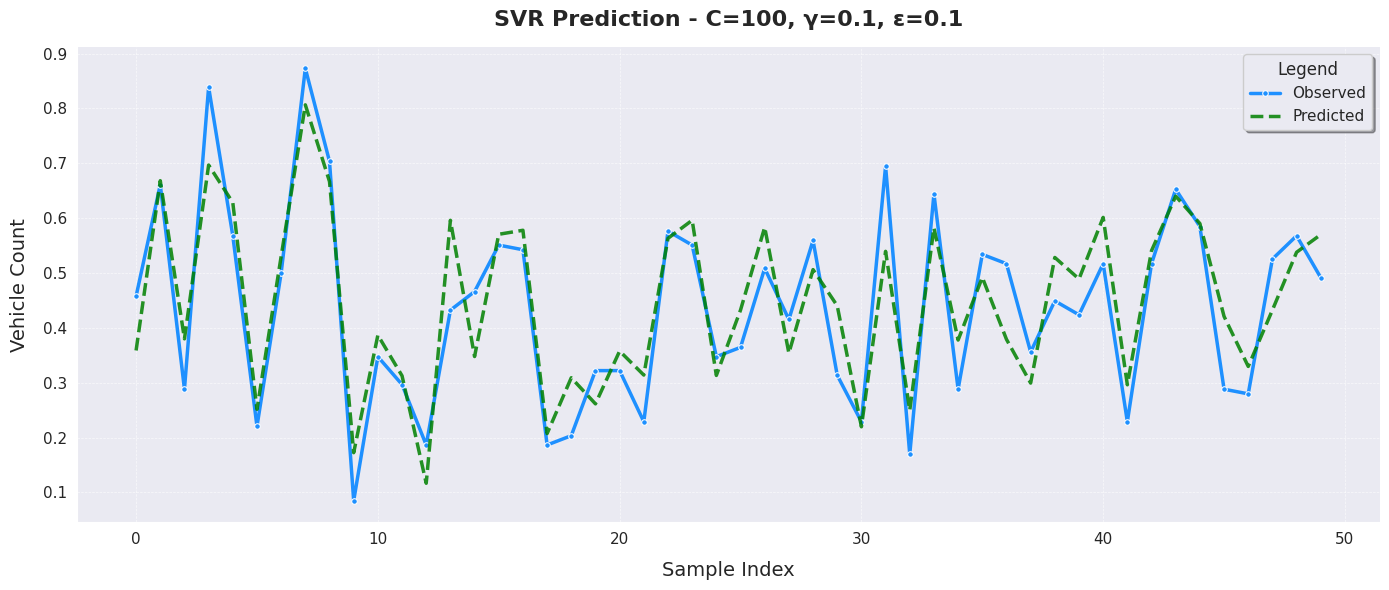

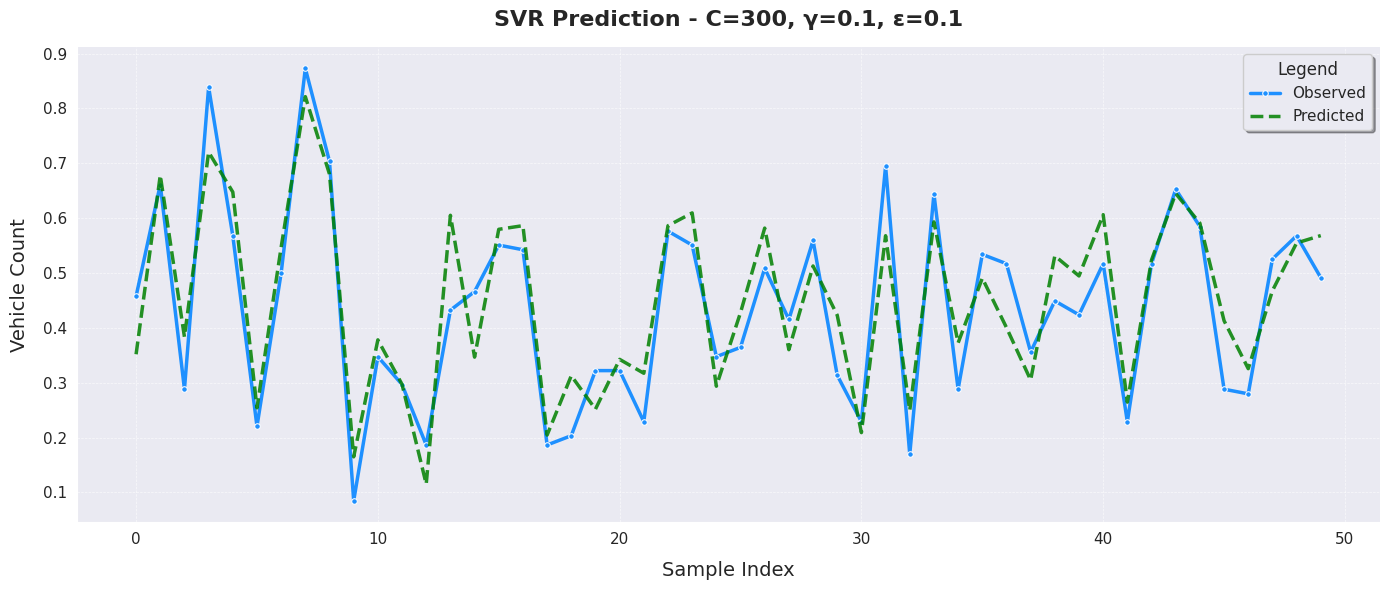

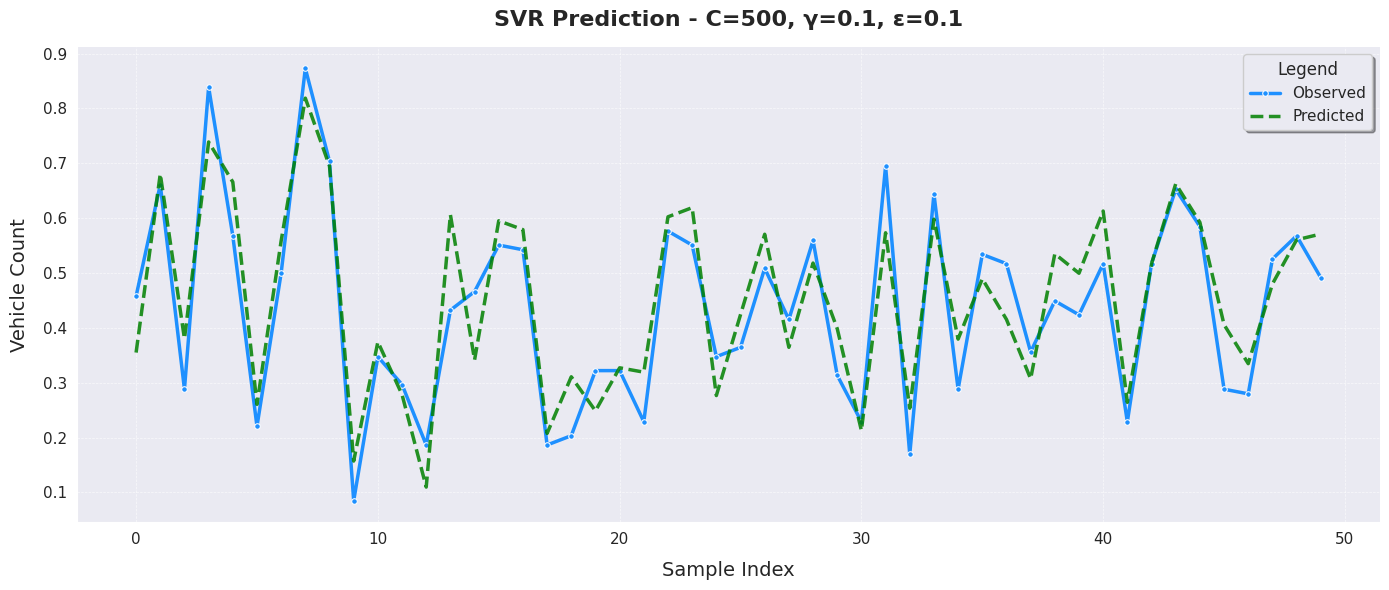

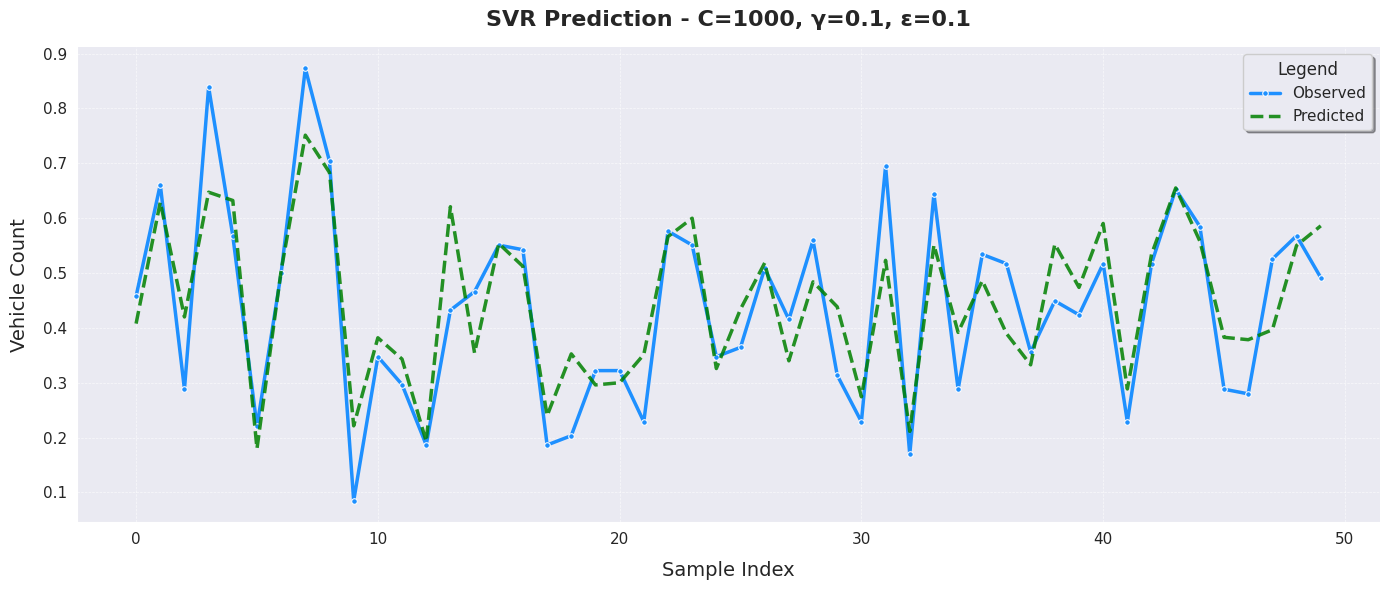

In [ ]:
# Step 1: Gather predictions by fitting SVR modls
svr_predictions = {}
# Repeat for every model.
for name, model in svr_modls.items():
  # Use training data to train the model.
    model.fit(X_traffec_tran, y_traffec_tran)
    # Forecast based on test data
    y_pred_test = model.predict(X_traffec_tast)
    # Save forecasts using the model name.
    svr_predictions[name] = y_pred_test
# Step 2: Create a Comparative DataFrame
comparison_svr_traffic_dfrm = pds.DataFrame({'Observed': y_traffec_tet.values})
# Include the forecasts from each model in the DataFrame.
for name, preds in svr_predictions.items():
  # Create new columns with the projected values.
    comparison_svr_traffic_dfrm[name] = preds
    # Plotting observed versus anticipated values for a specific model
def plot_svr_comparison(traffic_dfrm, column, n_samples, label):
# Decide on the size of the figure.
    mplt.figure(figsize=(14, 6))
    # Plot the values that were observed.
    sans.lineplot(x=range(n_samples), y=traffic_dfrm['Observed'].values[:n_samples],
                 label='Observed', color='dodgerblue', linewidth=2.5, marker='o', markersize=4)
    # Plot the anticipated values
    sans.lineplot(x=range(n_samples), y=traffic_dfrm[column].values[:n_samples],
                 label='Predicted', color='green', linestyle='--', linewidth=2.5, alpha=0.85)
    # Include the plot title and axis labels.
    mplt.xlabel('Sample Index', fontsize=14, labelpad=10)
    mplt.ylabel('Vehicle Count', fontsize=14, labelpad=10)
    mplt.title(f'SVR Prediction - {label}', fontsize=16, fontweight='bold', pad=15)
    # Use style to add legend
    mplt.legend(title='Legend', title_fontsize=12, fontsize=11, loc='best', frameon=True, fancybox=True, shadow=True)
    # Design the layout and ticks.
    mplt.xticks(fontsize=11)
    mplt.yticks(fontsize=11)
    # Take off the borders on the top and right.
    sans.despine()
     # Modify the arrangement to make the presentation cleaner.
    mplt.tight_layout()
    # Include gridlines
    mplt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    # Show the plot
    mplt.show()
# Use the first 50 samples to plot comparisons for various SVR modls.
plot_svr_comparison(comparison_svr_traffic_dfrm, "SVR (C=100, gamma=0.1, ε=0.1)", n_samples=50, label="C=100, γ=0.1, ε=0.1")
plot_svr_comparison(comparison_svr_traffic_dfrm, "SVR (C=300, gamma=0.1, ε=0.1)", n_samples=50, label="C=300, γ=0.1, ε=0.1")
plot_svr_comparison(comparison_svr_traffic_dfrm, "SVR (C=500, gamma=0.1, ε=0.1)", n_samples=50, label="C=500, γ=0.1, ε=0.1")
plot_svr_comparison(comparison_svr_traffic_dfrm, "SVR (C=1000, gamma=0.1, ε=0.1)", n_samples=50, label="C=1000, γ=0.1, ε=0.1")


# XGBRegressor Model

In [ ]:
# Various tree depth test values
depths = [5, 50, 100, 200]
# Varying the number of boosting rounds (trees)
n_estemators_list = [10, 100, 500, 1000]
# The performance metrics for every model configuration will be stored here.
xgb_results = []
# Examine XGBoost modls using various n_estimator and max_depth combinations.
for n_estemators in n_estemators_list:
    for depth in depths:
      # Set the XGBoost regressor's initial hyperparameters.
        model = XGBRegressor(
            # The ensemble's total number of trees
            n_estemators=n_estemators,
             # Each tree's maximum depth
            max_depth=depth,
            # Learning rate to increase
            learning_rate=0.1,
            # For each boosting round, use all available data.
            subsample=1.0,
            # Make use of every feature for every tree.
            colsample_bytree=1.0,
            # To ensure reproducibility, set a random seed.
            random_state=42,
            # Training logs for silence
            verbosity=0
        )
        # Get the model trained
        model.fit(X_traffec_tran, y_traffec_tran)
        # Forecast the training set
        y_pred_train = model.predict(X_traffec_tran)
        # Forecast based on the test set
        y_pred_test = model.predict(X_traffec_tast)

        # Note the current combination's results.
        xgb_results.append({
            # Tree count
            'n_estemators': n_estemators,
            # Depth of the tree
            'max_depth': depth,
            # R2 score for the train set
            'train R²': r2_score(y_traffec_tran, y_pred_train),
            # The test set's R2 score
            'test R²': r2_score(y_traffec_tet, y_pred_test),
            # MAE in a train
            'train MAE': mean_absolute_error(y_traffec_tran, y_pred_train),
            #MAE during the test
            'test MAE': mean_absolute_error(y_traffec_tet, y_pred_test),
            #MSE on the train
            'train MSE': mean_squared_error(y_traffec_tran, y_pred_train),
            #MSE during the test
            'test MSE': mean_squared_error(y_traffec_tet, y_pred_test)
        })
# Create a DataFrame from the dictionary list so that it can be easily viewed.
xgb_results_traffic_dfrm = pds.DataFrame(xgb_results)
# Title of the print
print("\nXGBoost Model Performance Summary:")
# Show results rounded to four decimal places (notebooks work best for this).
display(xgb_results_traffic_dfrm.round(4))



XGBoost Model Performance Summary:


,n_estemators,max_depth,train R²,test R²,train MAE,test MAE,train MSE,test MSE
0,10,5,0.9645,0.9545,0.0252,0.0275,0.0013,0.0016
1,10,50,1.0000,0.9548,0.0009,0.0287,0.0000,0.0016
2,10,100,1.0000,0.9548,0.0009,0.0287,0.0000,0.0016
3,10,200,1.0000,0.9548,0.0009,0.0287,0.0000,0.0016
4,100,5,0.9645,0.9545,0.0252,0.0275,0.0013,0.0016
5,100,50,1.0000,0.9548,0.0009,0.0287,0.0000,0.0016
6,100,100,1.0000,0.9548,0.0009,0.0287,0.0000,0.0016
7,100,200,1.0000,0.9548,0.0009,0.0287,0.0000,0.0016
8,500,5,0.9645,0.9545,0.0252,0.0275,0.0013,0.0016
9,500,50,1.0000,0.9548,0.0009,0.0287,0.0000,0.0016


# Comparison of XGB Model

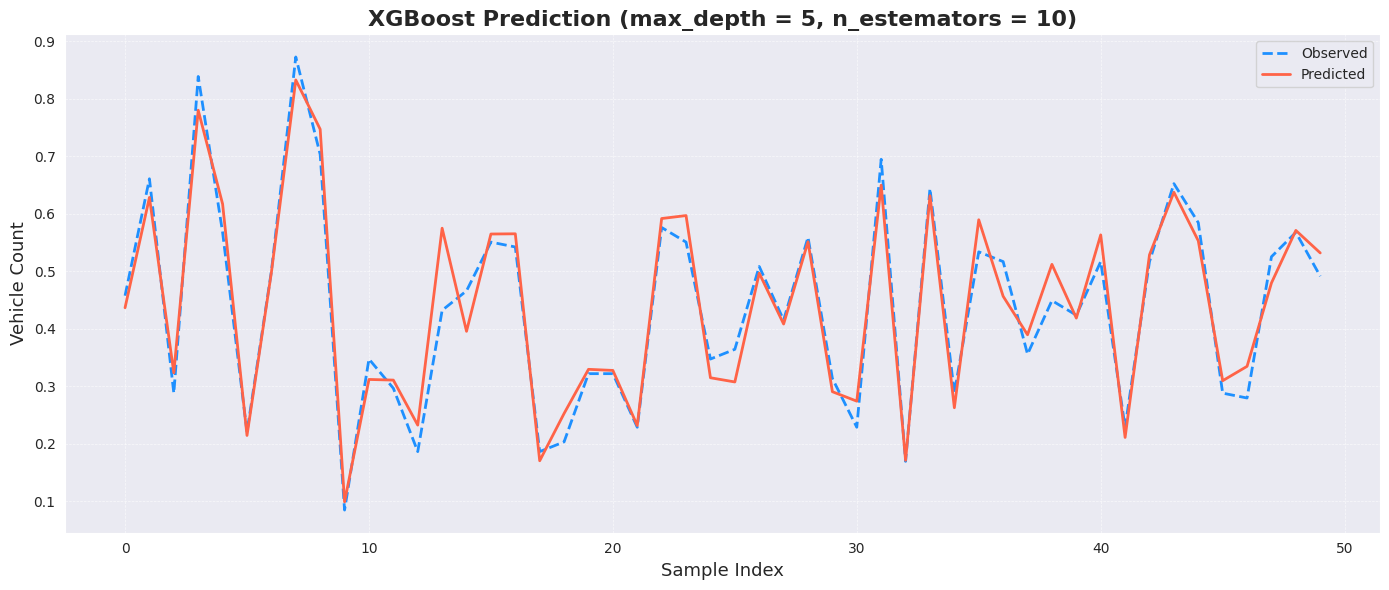

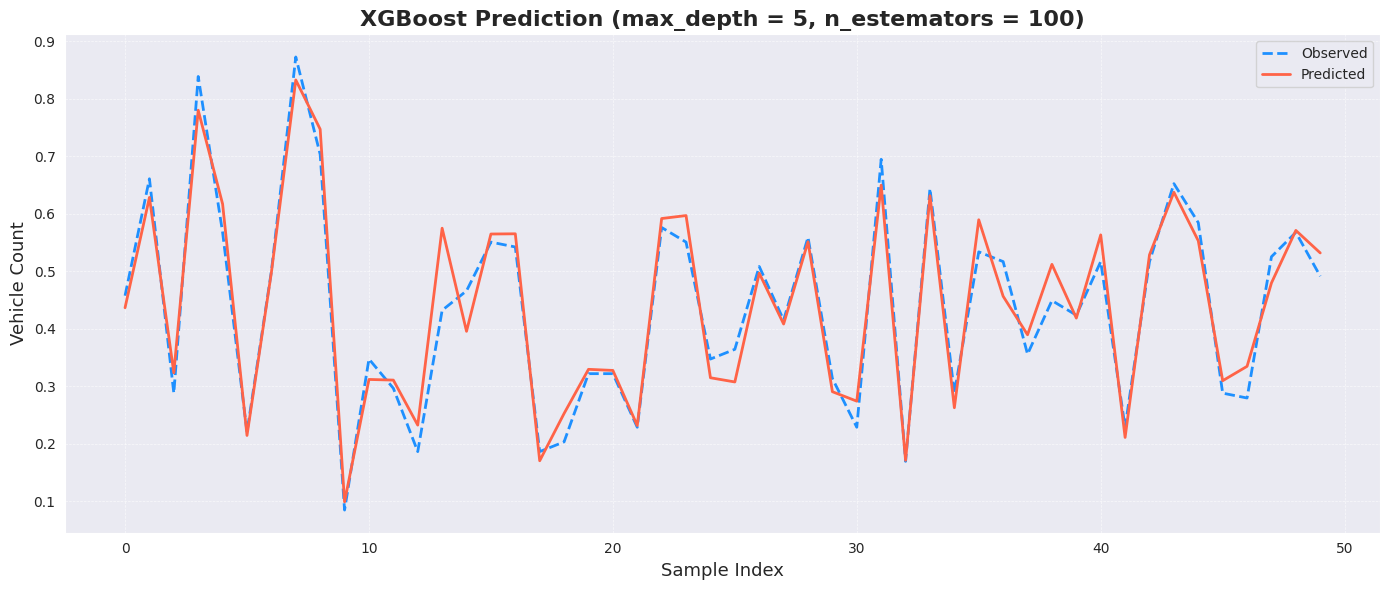

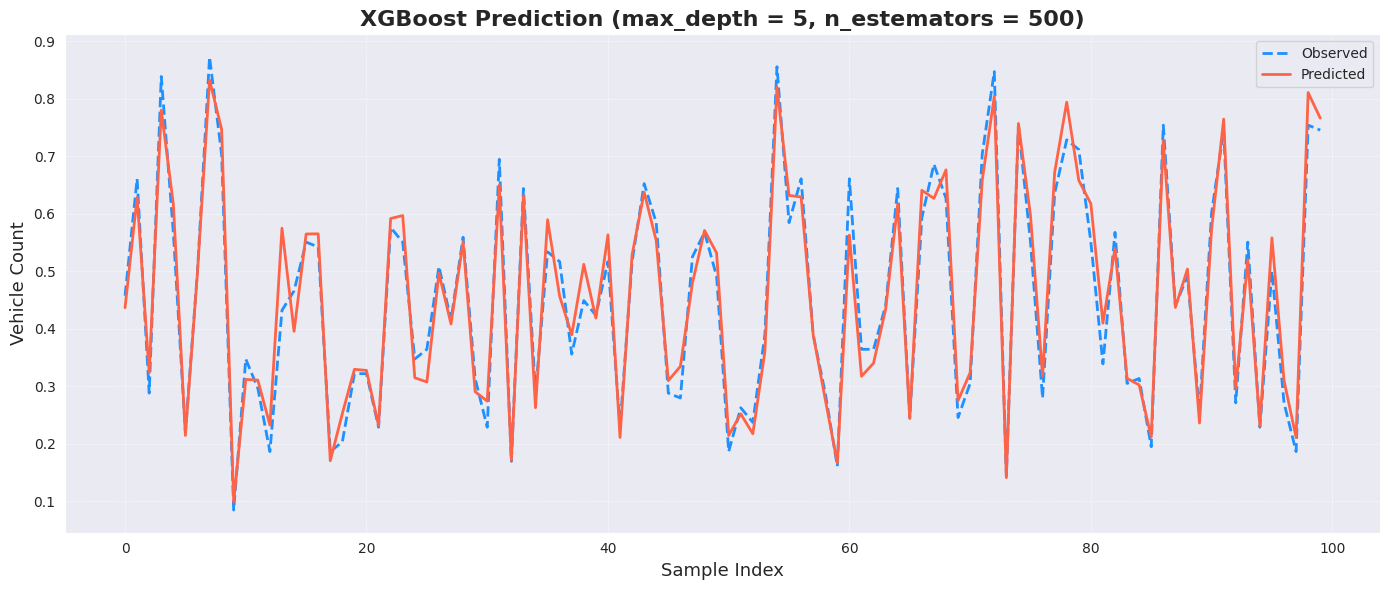

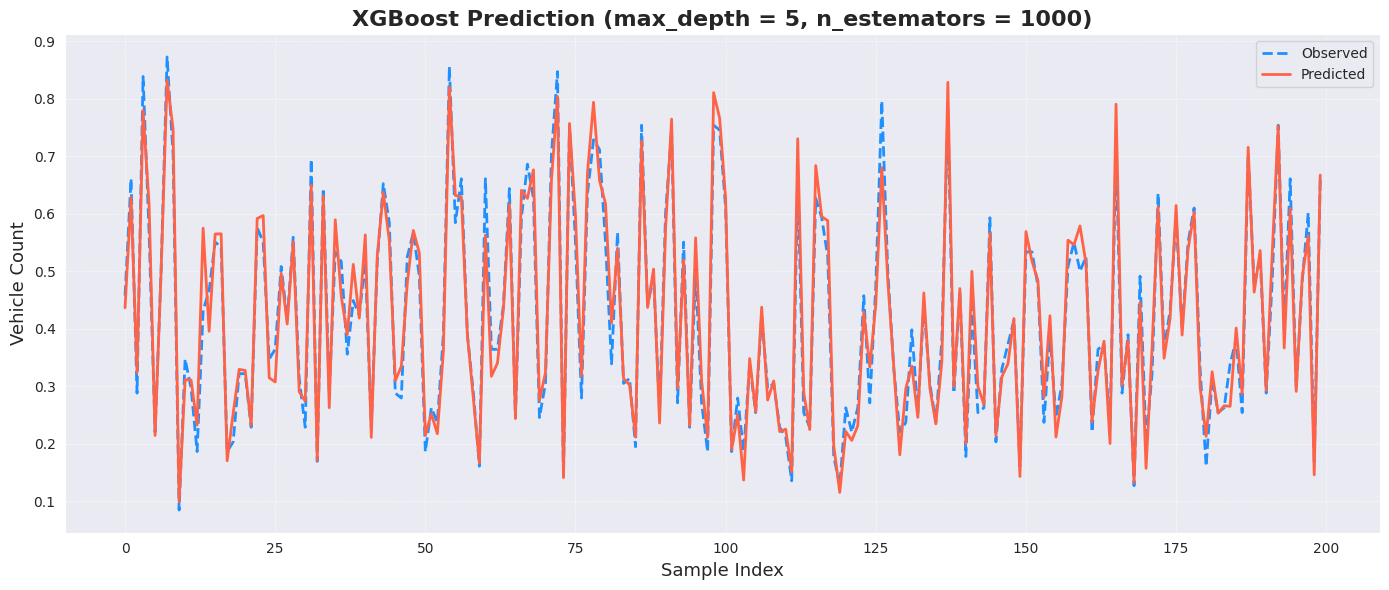

In [ ]:
# Dictionary to hold each XGBoost model's predictions
xgb_predictions = {}
# A list with varying numbers of trees (estimators) to test
n_estemators_list = [10, 100, 500, 1000]
# Repeat for every number of estimators.
for n_estemators in n_estemators_list:
  # Set up the XGBoost regressor using the current n_estemators and fixed max_depth.
    model = XGBRegressor(
        # The model's tree count
        n_estemators=n_estemators,
        # Trees with a fixed maximum depth
        max_depth=5,
        # Step size in updsates is controlled by learning rate.
        learning_rate=0.1,
        # For every boosting round, use all of the training data.
        subsample=1.0,
        # Make use of every feature for every tree.
        colsample_bytree=1.0,
        # Create a reproducible seed.
        random_state=42,
        # Turn off output messages
        verbosity=0
    )
    # Use training data to train the model.
    model.fit(X_traffec_tran, y_traffec_tran)
    # Produce forecasts using the test data.
    y_pred = model.predict(X_traffec_tast)
    xgb_predictions[f'XGB_trees_{n_estemators}'] = y_pred
# Combine predictions and observed values into a DataFrame
comparison_xgb_traffic_dfrm = pds.DataFrame({'Observed': y_traffec_tet.values})
# Use a descriptive key to store predictions in the dictionary.
for label, preds in xgb_predictions.items():
  # Step 2: Create a DataFrame by combining the predicted and observed values.
    comparison_xgb_traffic_dfrm[label] = preds
# Use the test set's actual observed values to begin the comparison DataFrame.
def plot_xgb_comparison(traffic_dfrm, column, n_samples, tree_label):
    # Create a new column with the predictions from each model.
    mplt.figure(figsize=(14, 6))
    # Plotting predicted versus observed values for a given model
    mplt.plot(traffic_dfrm['Observed'].values[:n_samples], label='Observed', color='dodgerblue', linestyle='--', linewidth=2)
    # Define the size of the figure.
    mplt.plot(traffic_dfrm[column].values[:n_samples], label='Predicted', color='tomato', linewidth=2)
    # Plot the values that were observed.
    mplt.title(f'XGBoost Prediction (max_depth = 5, n_estemators = {tree_label})', fontsize=16, fontweight='bold')
    # Plot the expected values for the specified model.
    mplt.xlabel('Sample Index', fontsize=13)
    # Use model information to set the plot title.
    mplt.ylabel('Vehicle Count', fontsize=13)
    # Legend of the show
    mplt.legend()
    # To improve readability, include a grid.
    mplt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    # Modify the arrangement for more aesthetically pleasing spacing
    mplt.tight_layout()
    # Show the plot
    mplt.show()
    # Plot comparisons with varying estimator counts
plot_xgb_comparison(comparison_xgb_traffic_dfrm, 'XGB_trees_10', n_samples=50, tree_label='10')
plot_xgb_comparison(comparison_xgb_traffic_dfrm, 'XGB_trees_100', n_samples=50, tree_label='100')
plot_xgb_comparison(comparison_xgb_traffic_dfrm, 'XGB_trees_500', n_samples=100, tree_label='500')
plot_xgb_comparison(comparison_xgb_traffic_dfrm, 'XGB_trees_1000', n_samples=200, tree_label='1000')


# Model Performance Comparison

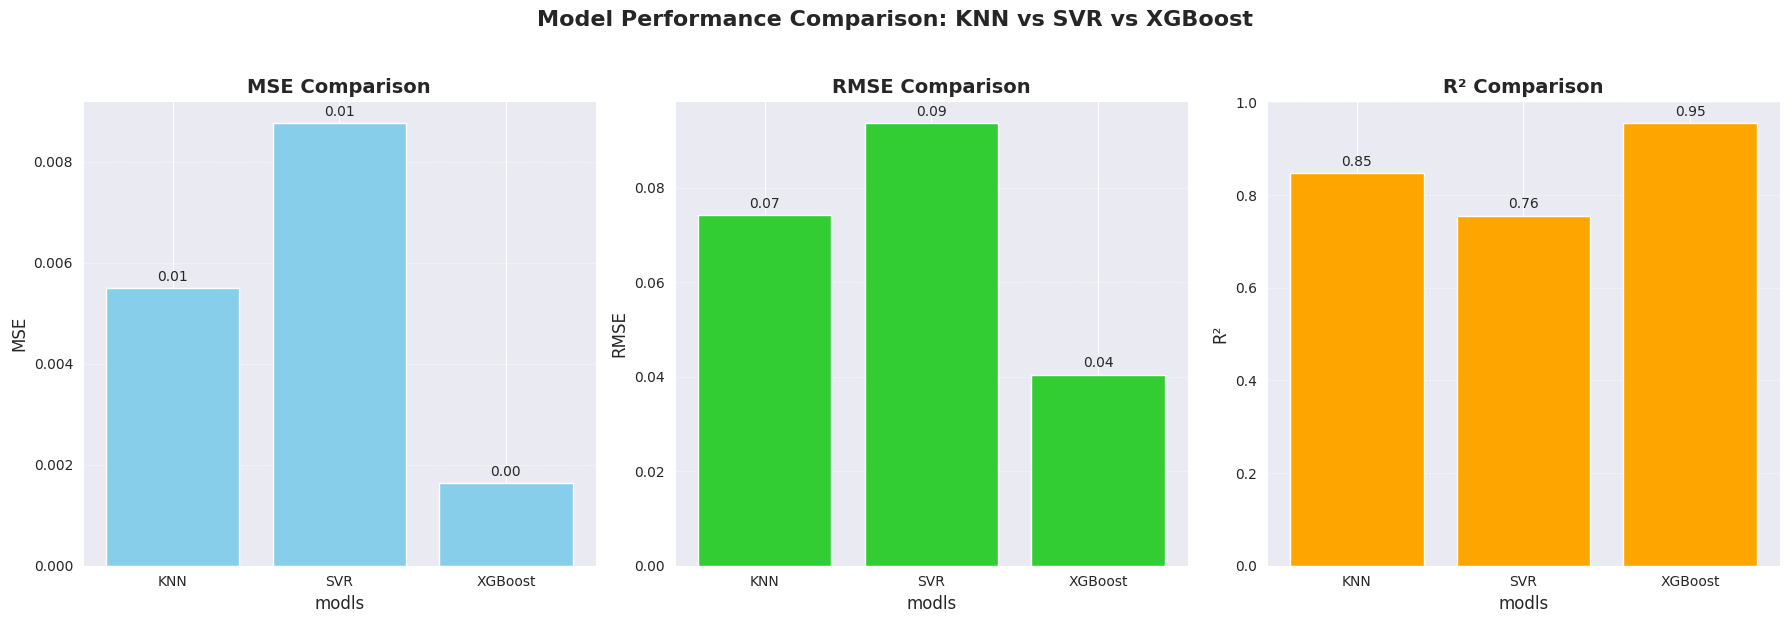

In [ ]:
# Using n=5 and leaf_size=60, extract predictions from the stored KNN model.
y_pred_knn = knn_predictions["KNN (n=5, leaf=60)"]
# Using C=1000, gamma=0.1, and epsilon=0.1, extract predictions from the stored SVR model.
y_pred_svr = svr_predictions["SVR (C=1000, gamma=0.1, ε=0.1)"]
# Take predictions out of the 1000-tree stored XGBoost model.
y_pred_xgb = xgb_predictions['XGB_trees_1000']

# KNN: Determine the test set's Mean Squared Error (MSE).
mse_knn = mean_squared_error(y_traffec_tet, y_pred_knn)
# KNN: Determine the Root Mean Squared Error (RMSE) by taking the MSE square root.
rmse_knn = npy.sqrt(mse_knn)
# KNN: Determine the goodness-of-fit by calculating the R2 score.
r2_knn = r2_score(y_traffec_tet, y_pred_knn)
# SVR: Determine the MSE for SVR forecasts.
mse_svr = mean_squared_error(y_traffec_tet, y_pred_svr)
# SVR: Determine the RMSE
rmse_svr = npy.sqrt(mse_svr)
# SVR: Determine the R2 score
r2_svr = r2_score(y_traffec_tet, y_pred_svr)
# XGBoost: Determine the MSE of XGBoost forecasts
mse_xgb = mean_squared_error(y_traffec_tet, y_pred_xgb)
# XGBoost: Determine the RMSE
rmse_xgb = npy.sqrt(mse_xgb)
# XGBoost: Determine the R2 score
r2_xgb = r2_score(y_traffec_tet, y_pred_xgb)

# List of x-axis model names
modls = ['KNN', 'SVR', 'XGBoost']
# A list of the MSE values for every model
mse_values = [mse_knn, mse_svr, mse_xgb]
# A list of each model's RMSE values
rmse_values = [rmse_knn, rmse_svr, rmse_xgb]
# A list of each model's R2 values
r2_values = [r2_knn, r2_svr, r2_xgb]
# Make a figure with three horizontally oriented subplots.
fig, axes = mplt.subplots(1, 3, figsize=(18, 6))
# Data and labels for every subplot
metrics = ['MSE', 'RMSE', 'R²']
# Plotting metric values
values = [mse_values, rmse_values, r2_values]
# Each metric's bar colors
colors = ['skyblue', 'limegreen', 'orange']
# Assign values, draw bars, and iterate through each subplot (metric).
for ax, metric, val, color in zip(axes, metrics, values, colors):
   # Create bars for every model.
    bars = ax.bar(modls, val, color=color)
# Write the value of each bar on top of it.
    for bar in bars:
      # x-position: the bar's center
        yval = bar.get_height()
        # Y-position: just above the bar
        ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.01 * max(val),
                f'{yval:.2f}', ha='center', va='bottom', fontsize=10)

     # Two decimal places in the text format
    ax.set_title(f'{metric} Comparison', fontsize=14, weight='bold')
     # Text centered
    ax.set_xlabel('modls', fontsize=12)
    # Assign axis labels and plot titles.
    ax.set_ylabel(metric, fontsize=12)
    # To improve readability, add horizontal grid lines.
    ax.tick_params(axis='both', labelsize=10)
    # Give the entire fig a main title.
    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.6)
# Modify the layout to guarantee tight spacing and avoid text overlap.
mplt.suptitle('Model Performance Comparison: KNN vs SVR vs XGBoost', fontsize=16, weight='bold', y=1.03)
mplt.tight_layout()
# show plot
mplt.show()
